# Nelson-Siegel (NS) con Enfasis Bayesiano

## Modelo

El modelo DNS de Diebold & Li (2006) especifica la curva de rendimientos como:

$$y(\tau) = \beta_0 + \beta_1 \frac{1 - e^{-\lambda\tau}}{\lambda\tau} + \beta_2 \left(\frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right) + \varepsilon$$

Donde:
- $\beta_0$: **Nivel** (long-end, todos los plazos contribuyen igual)
- $\beta_1$: **Pendiente** (diferencia corto vs largo plazo)
- $\beta_2$: **Curvatura** (joroba en plazos medios)
- $\lambda$: parámetro de decaimiento (fijo o estimado)

Como ya sabemos, los valores de $\beta_0, \beta_1$ y $\beta_2$ pueden ser estimado mediante OLS, pero si quisieramos estima $\lambda$ esto requeriria metodologias no lineales. Un enfoque posible para resolver este problema es mediante metodos bayesianos principalemnte nos enfocaremos en es uso de metropolis hasting para la estimacion conjunta de los parametros dado el conjunto de datos

In [2]:
import pymc as pm #libreria especializada en metodologia bayesianas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Datos
Seguiremos trabajando con los datos de rendimientos de tesoros de los EEUU, con los vencimientos de 1, 2, 3, 5, 7, 10, 20, 30 años, y trabajaremos para la estimacion de una unica fecha para analizar como es el proceso de estimar  $\beta_0, \beta_1$, $\beta_2$ y $\lambda$ con metodologia bayesiana con la ayuda de la libreria PyMC

[ 7.8551  8.3626  8.7469  9.2686  9.5924  9.8969 10.4428 10.7618]


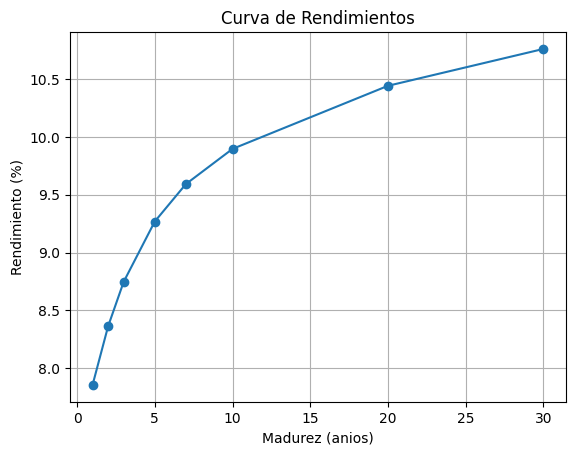

In [3]:
df = pd.read_csv("C:\\Users\\ADMON\\Documents\\Universidad\\Proyecto KMJ\\codigo\\Datos\\muestra_rend_EEUU.csv")
df.head()

maturities = [1, 2, 3, 5, 7, 10, 20, 30]

# Convierte a numerico para evitar dtype object en PyMC
yields = pd.to_numeric(df.iloc[0, 1:9], errors="coerce") # solo tomamos la primera fila (rendimientos) y las columnas de 1 a 8 (madurez)
if yields.isna().any():
    raise ValueError("Hay valores no numericos en los rendimientos (NaN despues de convertir).")

yields = yields.to_numpy(dtype=float)
print(yields)

plt.plot(maturities, yields, marker="o")
plt.title("Curva de Rendimientos")
plt.xlabel("Madurez (anios)")
plt.ylabel("Rendimiento (%)")
plt.grid()
plt.show()

In [ ]:
# Datos
tau = np.asarray(maturities, dtype=float)
y_obs = np.asarray(yields, dtype=float) / 100.0  # convertir de % a decimal

with pm.Model() as ns_model:

    # Priors (escala decimal de tasas)
    beta0 = pm.Normal("beta0", mu=0.05, sigma=0.05)
    beta1 = pm.Normal("beta1", mu=-0.01, sigma=0.05)
    beta2 = pm.Normal("beta2", mu=0.04, sigma=0.05)
    

    # Prior informativa para lambda en (0,1)
    lam = pm.Beta("lambda", alpha=12, beta=14)

    # Componentes del modelo
    term1 = (1 - pm.math.exp(-lam * tau)) / (lam * tau)
    term2 = term1 - pm.math.exp(-lam * tau)
    
    mu = beta0 + beta1 * term1 + beta2 * term2 

    # Error (escala decimal)
    sigma = pm.HalfNormal("sigma", sigma=0.01)

    # Likelihood
    y_like = pm.Normal("y_like", mu=mu, sigma=sigma, observed=y_obs)

    # Sampling
    trace = pm.sample(
        draws=3000,
        tune=500,
        target_accept=0.98,
        return_inferencedata=True,
        nuts_sampler="numpyro"
    )

# 0 32 7 0 divergece 0.95

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

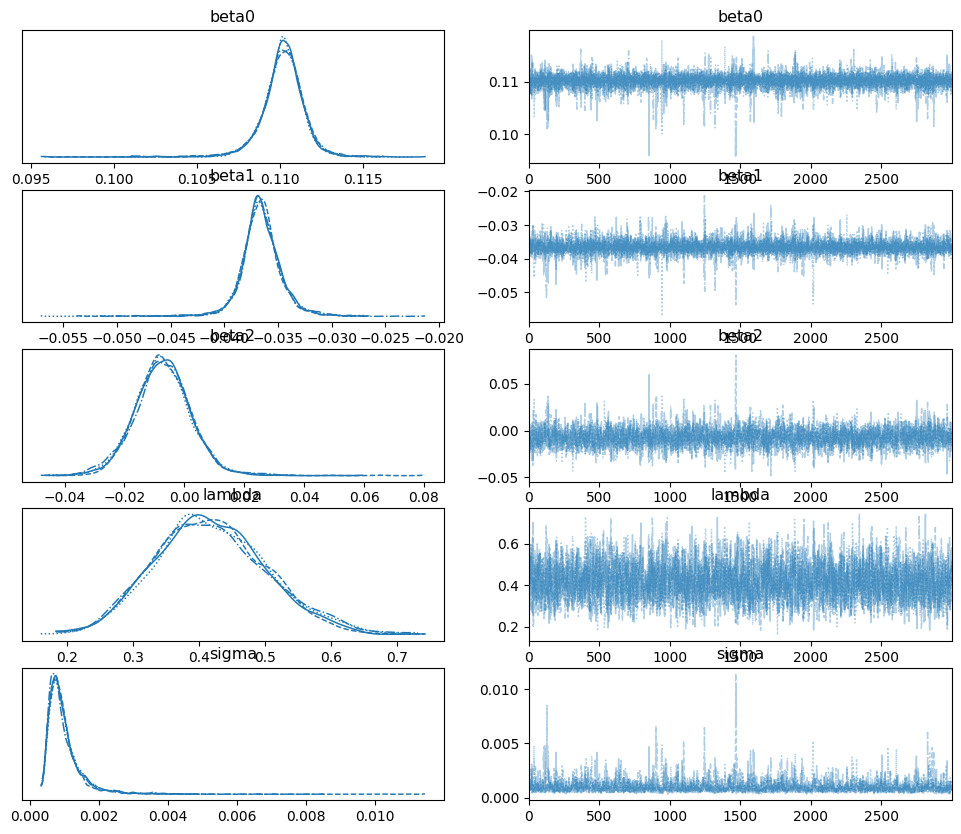

In [5]:
pm.plot_trace(trace, var_names=["beta0", "beta1", "beta2", "lambda", "sigma"])
plt.show()

In [10]:
summary = pm.summary(
    trace,
    var_names=["beta0", "beta1", "beta2", "lambda", "sigma"],
    hdi_prob=0.95
)

print(summary)

print("\nChequeo rapido de convergencia:")
print("r_hat max:", summary["r_hat"].max())
print("ess_bulk min:", summary["ess_bulk"].min())
print("ess_tail min:", summary["ess_tail"].min())

         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta0   0.110  0.001     0.108      0.113      0.000    0.000    7637.0   
beta1  -0.036  0.002    -0.040     -0.033      0.000    0.000    5774.0   
beta2  -0.007  0.009    -0.026      0.010      0.000    0.000    2641.0   
lambda  0.417  0.084     0.260      0.585      0.002    0.001    2502.0   
sigma   0.001  0.000     0.000      0.002      0.000    0.000    2020.0   

        ess_tail  r_hat  
beta0     4724.0    1.0  
beta1     4249.0    1.0  
beta2     3499.0    1.0  
lambda    3500.0    1.0  
sigma     2904.0    1.0  

Chequeo rapido de convergencia:
r_hat max: 1.0
ess_bulk min: 2020.0
ess_tail min: 2904.0


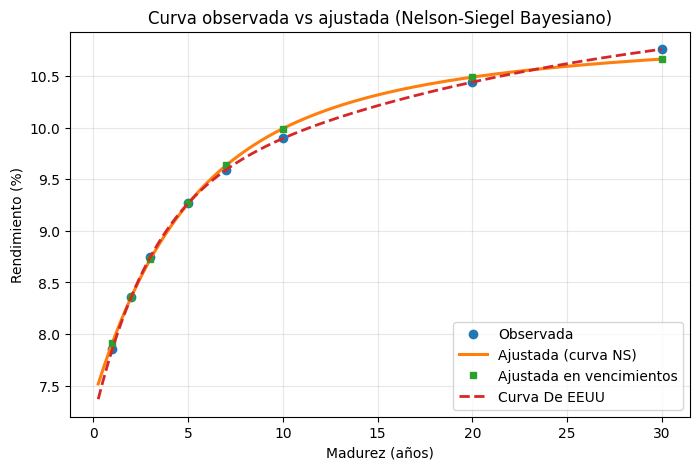

Parametros medios posteriores (escala decimal):
beta0=0.1102, beta1=-0.0365, beta2=-0.0074, lambda=0.417088


In [ ]:
# Medias posteriores de parametros
beta0_hat = float(trace.posterior["beta0"].mean().values)
beta1_hat = float(trace.posterior["beta1"].mean().values)
beta2_hat = float(trace.posterior["beta2"].mean().values)
lambda_hat = float(trace.posterior["lambda"].mean().values)

# Curva ajustada Nelson-Siegel en vencimientos observados (escala decimal)
term1_hat = (1 - np.exp(-lambda_hat * tau)) / (lambda_hat * tau)
term2_hat = term1_hat - np.exp(-lambda_hat * tau)
y_fit = beta0_hat + beta1_hat * term1_hat + beta2_hat * term2_hat

# Curva ajustada suave en una malla continua de vencimientos
# Nota: se evita tau=0 para no dividir entre cero
tau_grid = np.linspace(0.25, 30, 300)
term1_grid = (1 - np.exp(-lambda_hat * tau_grid)) / (lambda_hat * tau_grid)
term2_grid = term1_grid - np.exp(-lambda_hat * tau_grid)
y_fit_grid = beta0_hat + beta1_hat * term1_grid + beta2_hat * term2_grid

# Curva adicional con parametros del comentario final (en %)
beta0_c = df["BETA0"].iloc[0]  # -4.40092278524114
beta1_c = df["BETA1"].iloc[0]  # -618.930843769627
beta2_c = df["BETA2"].iloc[0]  # 619.464293142355
beta3_c = df["BETA3"].iloc[0]  # 4.37388682468365
lambda1_c = df["TAU1"].iloc[0] # 4.36076744378776
lambda2_c = df["TAU2"].iloc[0] #

term1_c = (1 - np.exp(-tau_grid / lambda1_c )) / (tau_grid / lambda1_c)
term2_c = term1_c - np.exp(-tau_grid / lambda1_c)
term3_c = (1 - np.exp(-tau_grid / lambda2_c)) / (tau_grid / lambda2_c) - np.exp(-tau_grid / lambda2_c)
y_fit_comment_pct = beta0_c + beta1_c * term1_c + beta2_c * term2_c + beta3_c * term3_c

# Convertir a porcentaje para graficar
y_obs_pct = y_obs * 100
y_fit_pct = y_fit * 100
y_fit_grid_pct = y_fit_grid * 100

plt.figure(figsize=(8, 5))
plt.plot(tau, y_obs_pct, "o", ms=6, label="Observada")
plt.plot(tau_grid, y_fit_grid_pct, "-", lw=2.2, label="Ajustada (curva NS)")
plt.plot(tau, y_fit_pct, "s", ms=5, label="Ajustada en vencimientos")
plt.plot(tau_grid, y_fit_comment_pct, "--", lw=2.0, label="Curva De EEUU")
plt.title("Curva observada vs ajustada (Nelson-Siegel Bayesiano)")
plt.xlabel("Madurez (años)")
plt.ylabel("Rendimiento (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Parametros medios posteriores (escala decimal):")
print(f"beta0={beta0_hat:.4f}, beta1={beta1_hat:.4f}, beta2={beta2_hat:.4f}, lambda={lambda_hat:.6f}")



In [41]:
# Diagnostico compacto de la corrida actual
divergences = int(trace.sample_stats["diverging"].sum().values)
n_draws = int(np.prod(trace.sample_stats["diverging"].shape))

summary_chk = pm.summary(
    trace,
    var_names=["beta0", "beta1", "beta2", "lambda", "sigma"],
    hdi_prob=0.95
)

print(f"Divergencias: {divergences} de {n_draws} draws")
print("r_hat max:", float(summary_chk["r_hat"].max()))
print("ess_bulk min:", float(summary_chk["ess_bulk"].min()))
print("ess_tail min:", float(summary_chk["ess_tail"].min()))

Divergencias: 0 de 8000 draws
r_hat max: 1.0
ess_bulk min: 1215.0
ess_tail min: 1420.0
